In [ ]:
# CyberCleanAir Hackathon 2026
# ============================================================

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [ ]:
# CONFIGURATION
# ============================================================

API_KEY = "A49B43A7-2F67-11F1-B596-4201AC1DC123"
TARGET_SENSOR = 104412  # Delphia Pondside
NEIGHBOR_SENSORS = [124995, 196269]  # Pisgah Forest, Shining Rock Wilderness
NORMAL_AQI = 5  # µg/m³ baseline normal PM2.5
FIELDS = "pm2.5_atm"

In [ ]:
# Time windows (UTC timestamps)
EVENT_START = 1743465600   # 2026-04-01 00:00
EVENT_END = 1743681600     # 2026-04-03 12:00
CLEAN_START = 1743206400   # 2026-03-29 00:00
CLEAN_END = 1743379200     # 2026-03-31 00:00

EXPECTED_READINGS = 360  # expected readings in event period

In [ ]:
# FUNCTION: FETCH SENSOR DATA
# ============================================================

def fetch_sensor_data(sensor_id: int, start_ts: int, end_ts: int) -> pd.DataFrame:
    """
    Fetch PM2.5 sensor data from PurpleAir API.
    Returns cleaned dataframe with columns: timestamp, sensor_id, value
    """
    url = f"https://api.purpleair.com/v1/sensors/{sensor_id}/history"
    headers = {"X-API-Key": API_KEY}
    params = {
        "fields": FIELDS,
        "start_timestamp": start_ts,
        "end_timestamp": end_ts
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame(data["data"], columns=data["fields"])
    df['sensor_id'] = sensor_id
    df = df.rename(columns={'time_stamp': 'timestamp', 'pm2.5_atm': 'value'})
    df = df.sort_values('timestamp').reset_index(drop=True)

    return df[['timestamp', 'sensor_id', 'value']]

In [ ]:
# FETCH DATA
# ============================================================

# Event period
df_target = fetch_sensor_data(TARGET_SENSOR, EVENT_START, EVENT_END)
df_neighbor1 = fetch_sensor_data(NEIGHBOR_SENSORS[0], EVENT_START, EVENT_END)
df_neighbor2 = fetch_sensor_data(NEIGHBOR_SENSORS[1], EVENT_START, EVENT_END)

print(f"Event period readings:")
print(f"  Target: {len(df_target)}")
print(f"  Neighbor 1: {len(df_neighbor1)}")
print(f"  Neighbor 2: {len(df_neighbor2)}")

# Clean period (used for replay attack)
df_clean = fetch_sensor_data(TARGET_SENSOR, CLEAN_START, CLEAN_END)
print(f"\nClean period readings: {len(df_clean)}")
print(f"Clean period mean PM2.5: {df_clean['value'].mean():.2f} µg/m³")

Event period readings:
  Target: 360
  Neighbor 1: 295
  Neighbor 2: 360

Clean period readings: 288
Clean period mean PM2.5: 23.97 µg/m³


In [ ]:
# FUNCTION: COMPUTE TRUST SCORE
# ============================================================

def compute_trust_score(df_sensor: pd.DataFrame, df_neighbor1: pd.DataFrame,
                        df_neighbor2: pd.DataFrame, expected_readings: int = 360):
    """
    Computes sensor trust score based on three categories:
    1. Data Quality (Q): missing, accuracy, completeness
    2. Statistical Behavior (S): variance, outliers, rate of change, repetition
    3. Neighbor Comparison (N): value difference, correlation with neighbors
    Returns: trust_score, Q, S, N, detail_dict
    """
    values = df_sensor['value'].dropna().reset_index(drop=True)
    detail = {}

    # ------------------------
    # CATEGORY 1: DATA QUALITY
    # ------------------------
    missing_count = df_sensor['value'].isnull().sum()
    q_missing = ((len(df_sensor) - missing_count) / len(df_sensor)) * 100
    detail['Q_missing_values'] = q_missing

    valid_values = values.between(0, 100)
    q_accuracy = (valid_values.sum() / len(values)) * 100
    detail['Q_accuracy'] = q_accuracy

    q_completeness = min((len(values) / expected_readings) * 100, 100)
    detail['Q_completeness'] = q_completeness

    Q = (q_missing + q_accuracy + q_completeness) / 3

    # ------------------------
    # CATEGORY 2: STATISTICAL BEHAVIOR
    # ------------------------
    mean_val = values.mean()
    std_val = values.std() + 1e-6

    # Flatline variance metric
    s_variance = min((values.var() / 200) * 100, 100)
    detail['S_variance'] = s_variance

    # Outlier detection using z-score
    z_scores = np.abs((values - mean_val) / std_val)
    outliers = (z_scores > 3).sum()
    s_outliers = max(0, 100 - (outliers / len(values) * 100 * 10))
    detail['S_outliers'] = s_outliers

    # Rate of change
    roc = values.diff().abs()
    jump_threshold = 3 * (roc.std() + 1e-6)
    extreme_jumps = (roc > jump_threshold).sum()
    s_rate_change = max(0, 100 - (extreme_jumps / len(values) * 100 * 10))
    detail['S_rate_of_change'] = s_rate_change

    # Repetition (detect replay)
    repeated_count = (values.diff() == 0).sum()
    repeat_ratio = repeated_count / len(values)
    s_repetition = max(0, 100 - (repeat_ratio * 100 * 2))
    detail['S_repetition'] = s_repetition

    S = (s_variance + s_outliers + s_rate_change + s_repetition) / 4

    # ------------------------
    # CATEGORY 3: NEIGHBOR COMPARISON
    # ------------------------
    df_merged = df_sensor[['timestamp','value']].merge(
        df_neighbor1[['timestamp','value']].rename(columns={'value':'n1'}),
        on='timestamp', how='inner'
    ).merge(
        df_neighbor2[['timestamp','value']].rename(columns={'value':'n2'}),
        on='timestamp', how='inner'
    )

    if len(df_merged) > 10:
        target_vals = df_merged['value']
        neighbor_mean = (df_merged['n1'] + df_merged['n2']) / 2

        # N1: Average difference from neighbors
        avg_diff = np.abs(target_vals - neighbor_mean).mean()
        n_value_diff = max(0, 100 - (avg_diff / 50 * 100))
        detail['N_value_difference'] = n_value_diff

        # N2: Correlation with neighbors
        corr1 = target_vals.corr(df_merged['n1'])
        corr2 = target_vals.corr(df_merged['n2'])
        avg_corr = (corr1 + corr2) / 2
        n_corr = np.clip((avg_corr + 1) / 2 * 100, 0, 100)
        detail['N_correlation'] = n_corr
    else:
        n_value_diff = 0
        n_corr = 0
        detail['N_value_difference'] = 0
        detail['N_correlation'] = 0

    N = (n_value_diff + n_corr) / 2

    trust_score = (Q + S + N) / 3
    return trust_score, Q, S, N, detail

In [ ]:
# BASELINE TRUST SCORE
# ============================================================

base_score, base_Q, base_S, base_N, base_detail = compute_trust_score(
    df_target, df_neighbor1, df_neighbor2
)
print(f"Baseline Trust Score: {base_score:.2f}/100 (Q={base_Q:.2f}, S={base_S:.2f}, N={base_N:.2f})")

Baseline Trust Score: 81.95/100 (Q=100.00, S=60.28, N=85.56)


In [ ]:
# ATTACK SIMULATIONS
# ============================================================

def simulate_attacks(df_target, df_clean, neighbors):
    """
    Simulate 3 attacks: Replay, Flatline, Threshold Manipulation
    Returns dictionary of attack dataframes and scores
    """
    results = {}

    # --- Replay Attack: use clean period repeated ---
    df_replay = df_target.copy()
    clean_values = df_clean['value'].values
    repeat_count = int(np.ceil(len(df_replay) / len(clean_values)))
    df_replay['value'] = np.tile(clean_values, repeat_count)[:len(df_replay)]
    replay_score, replay_Q, replay_S, replay_N, replay_detail = compute_trust_score(
        df_replay, neighbors[0], neighbors[1]
    )
    results['Replay'] = {
        'df': df_replay, 'score': replay_score, 'Q': replay_Q, 'S': replay_S,
        'N': replay_N, 'detail': replay_detail
    }

    # --- Flatline Attack: constant clean mean ---
    df_flatline = df_target.copy()
    flat_val = df_clean['value'].mean()
    df_flatline['value'] = flat_val
    flatline_score, flatline_Q, flatline_S, flatline_N, flatline_detail = compute_trust_score(
        df_flatline, neighbors[0], neighbors[1]
    )
    results['Flatline'] = {
        'df': df_flatline, 'score': flatline_score, 'Q': flatline_Q, 'S': flatline_S,
        'N': flatline_N, 'detail': flatline_detail
    }

    # --- Threshold Manipulation: reduce values 30% ---
    df_threshold = df_target.copy()
    df_threshold['value'] = df_threshold['value'] * 0.7
    threshold_score, threshold_Q, threshold_S, threshold_N, threshold_detail = compute_trust_score(
        df_threshold, neighbors[0], neighbors[1]
    )
    results['Threshold'] = {
        'df': df_threshold, 'score': threshold_score, 'Q': threshold_Q, 'S': threshold_S,
        'N': threshold_N, 'detail': threshold_detail
    }

    return results

In [ ]:
attack_results = simulate_attacks(df_target, df_clean, [df_neighbor1, df_neighbor2])

In [ ]:
# VISUALIZATION FUNCTIONS
# ============================================================

def plot_attack_scenario(df_target, scenario_name, df_attack, detail, trust_score, Q, S, N, color):
    """
    Plots PM2.5 time series vs baseline and bar chart of metric scores
    """
    fig, axes = plt.subplots(1, 2, figsize=(16,5))

    # --- Time series plot ---
    df_target['datetime'] = pd.to_datetime(df_target['timestamp'], unit='s')
    df_attack['datetime'] = pd.to_datetime(df_attack['timestamp'], unit='s')

    axes[0].plot(df_target['datetime'], df_target['value'], color='lightgray', label='Original', zorder=1)
    axes[0].plot(df_attack['datetime'], df_attack['value'], color=color, marker='o', markersize=2, label=scenario_name, zorder=2)
    axes[0].axhline(y=50, color='red', linestyle='--', label='Alert Threshold')
    axes[0].axhline(y=NORMAL_AQI, color='gray', linestyle='--', label='Normal AQI')
    axes[0].set_title(f"{scenario_name} - PM2.5 Readings")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("PM2.5 (µg/m³)")
    axes[0].legend(fontsize=8)
    axes[0].tick_params(axis='x', rotation=45)

    # --- Metric bar chart ---
    labels = [k.replace('_',' ').title() for k in detail.keys()]
    values = list(detail.values())
    cat_colors = ['steelblue' if k.startswith('Q') else 'darkorange' if k.startswith('S') else 'green' for k in detail.keys()]
    bars = axes[1].barh(labels, values, color=cat_colors, alpha=0.8)
    axes[1].axvline(70, color='gray', linestyle='--', linewidth=1)
    axes[1].set_xlim(0, 100)
    axes[1].set_title(f"{scenario_name} Metrics\nTrust Score={trust_score:.1f}/100 (Q={Q:.1f}, S={S:.1f}, N={N:.1f})")

    for bar, val in zip(bars, values):
        axes[1].text(min(val + 1, 95), bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8)

    legend_elements = [
        Patch(facecolor='steelblue', label=f'Q={Q:.1f}'),
        Patch(facecolor='darkorange', label=f'S={S:.1f}'),
        Patch(facecolor='green', label=f'N={N:.1f}'),
    ]
    axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()


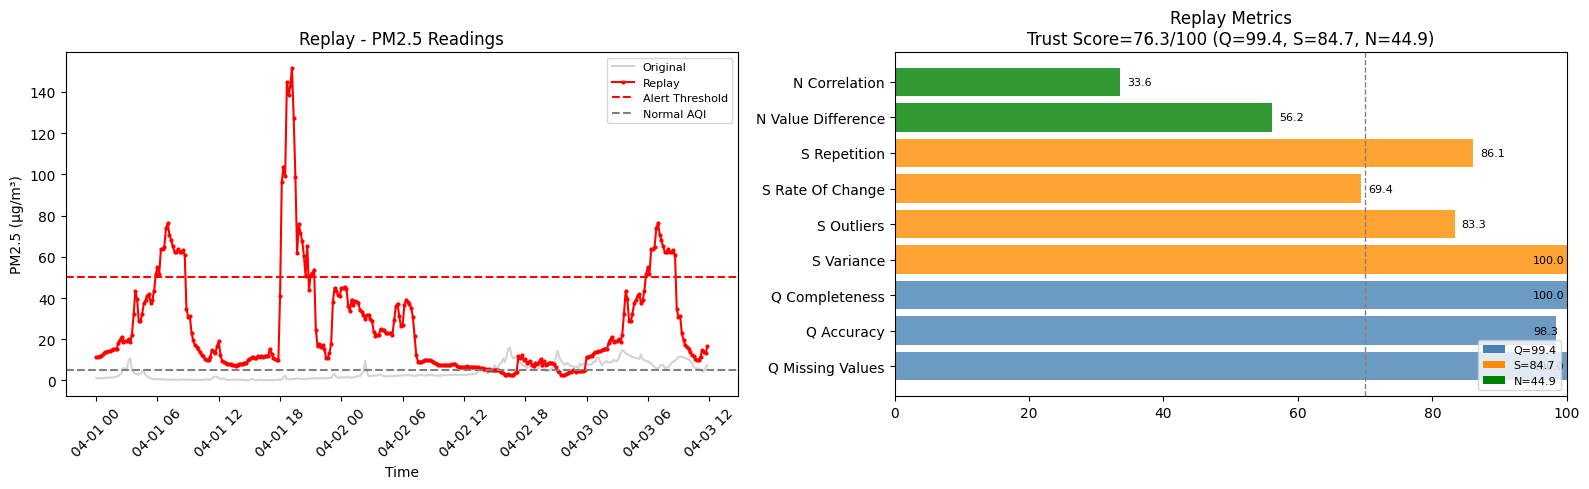

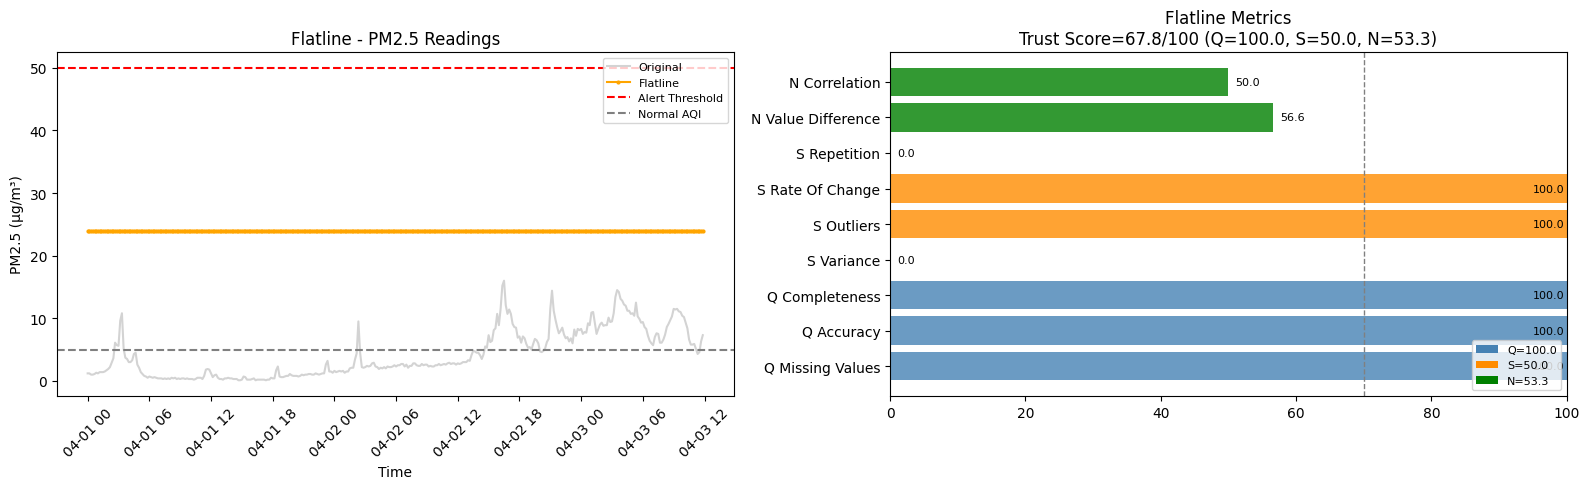

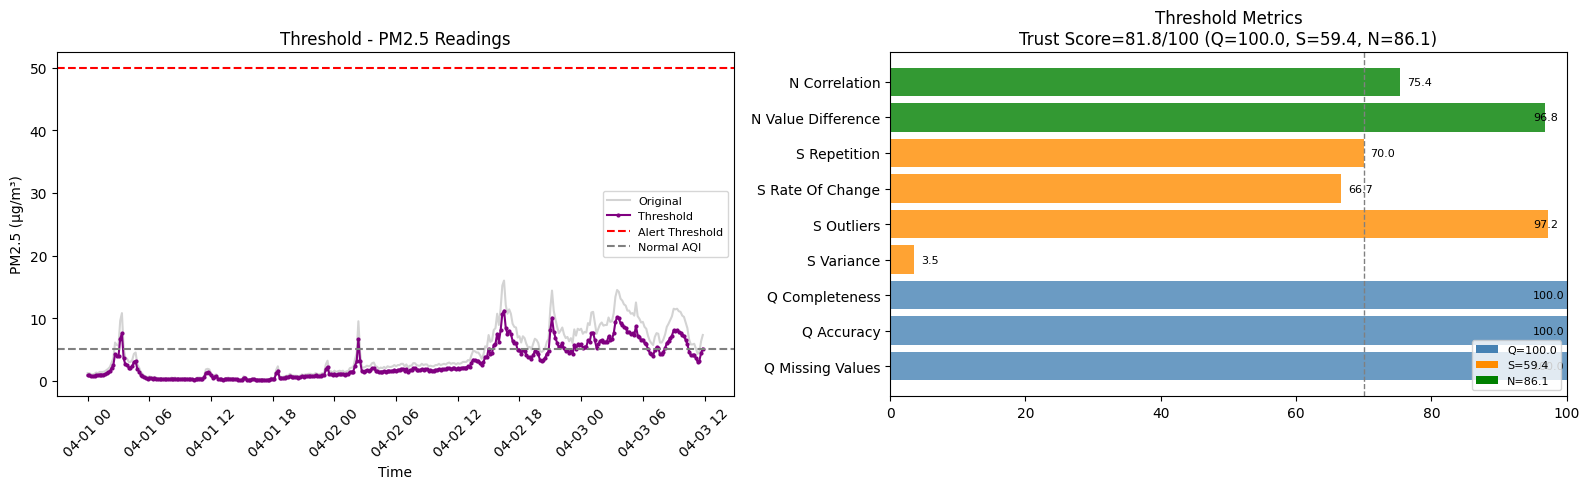

In [ ]:
# PLOT EACH SCENARIO
# ============================================================

colors = {'Replay': 'red', 'Flatline': 'orange', 'Threshold': 'purple'}
for attack_name, attack_data in attack_results.items():
    plot_attack_scenario(
        df_target, attack_name, attack_data['df'], attack_data['detail'],
        attack_data['score'], attack_data['Q'], attack_data['S'], attack_data['N'],
        colors[attack_name]
    )

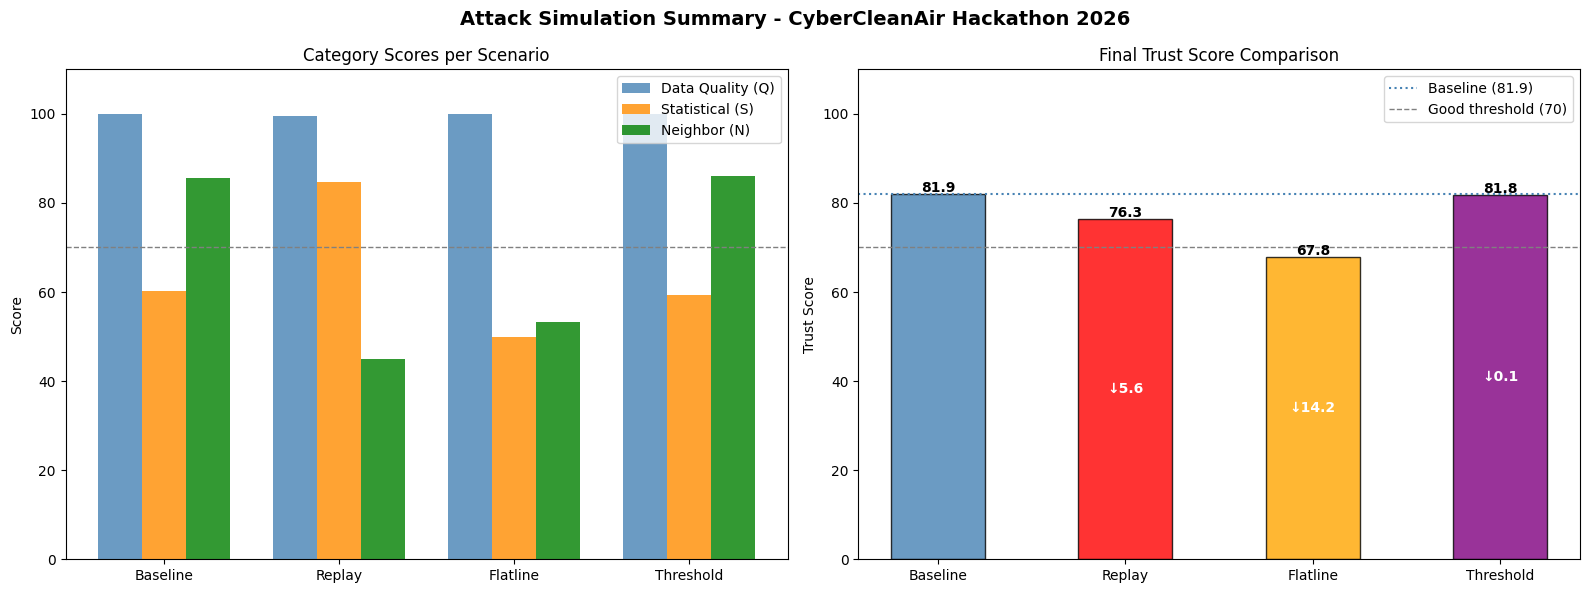

In [ ]:
# SUMMARY CHART: All Scenarios
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(16,6))
labels = ['Baseline', 'Replay', 'Flatline', 'Threshold']

# Category scores
Q_vals = [base_Q] + [attack_results[a]['Q'] for a in attack_results]
S_vals = [base_S] + [attack_results[a]['S'] for a in attack_results]
N_vals = [base_N] + [attack_results[a]['N'] for a in attack_results]

x = np.arange(len(labels))
width = 0.25
ax[0].bar(x - width, Q_vals, width, label='Data Quality (Q)', color='steelblue', alpha=0.8)
ax[0].bar(x, S_vals, width, label='Statistical (S)', color='darkorange', alpha=0.8)
ax[0].bar(x + width, N_vals, width, label='Neighbor (N)', color='green', alpha=0.8)
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_ylim(0, 110)
ax[0].set_ylabel("Score")
ax[0].set_title("Category Scores per Scenario")
ax[0].axhline(70, color='gray', linestyle='--', linewidth=1)
ax[0].legend()

# Final trust scores
final_scores = [base_score] + [attack_results[a]['score'] for a in attack_results]
bar_colors = ['steelblue', 'red', 'orange', 'purple']
bars = ax[1].bar(labels, final_scores, color=bar_colors, alpha=0.8, edgecolor='black', width=0.5)

for bar, score in zip(bars, final_scores):
    ax[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{score:.1f}', ha='center', fontweight='bold')

for bar, score in zip(bars[1:], final_scores[1:]):
    drop = base_score - score
    ax[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'↓{drop:.1f}', ha='center', va='center', color='white', fontweight='bold')

ax[1].axhline(y=base_score, color='steelblue', linestyle=':', linewidth=1.5, label=f'Baseline ({base_score:.1f})')
ax[1].axhline(y=70, color='gray', linestyle='--', linewidth=1, label='Good threshold (70)')
ax[1].set_ylim(0,110)
ax[1].set_ylabel("Trust Score")
ax[1].set_title("Final Trust Score Comparison")
ax[1].legend()

plt.suptitle("Attack Simulation Summary - CyberCleanAir Hackathon 2026", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()